Primeras filas del dataset:
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping T

C:\Users\VICTOR\AppData\Local\Temp\ipykernel_21236\348801904.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include="object").columns


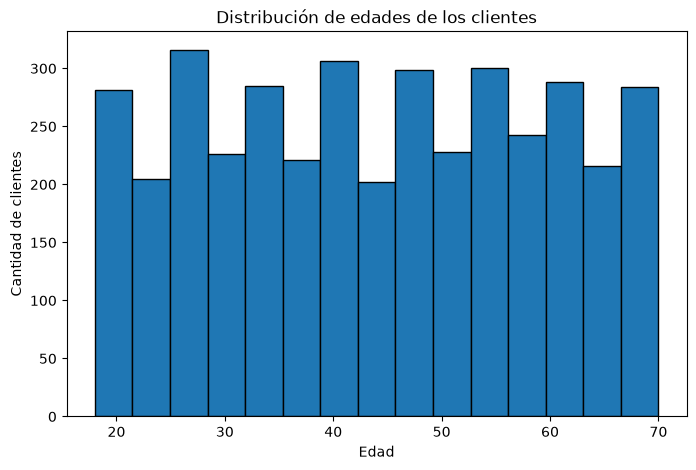

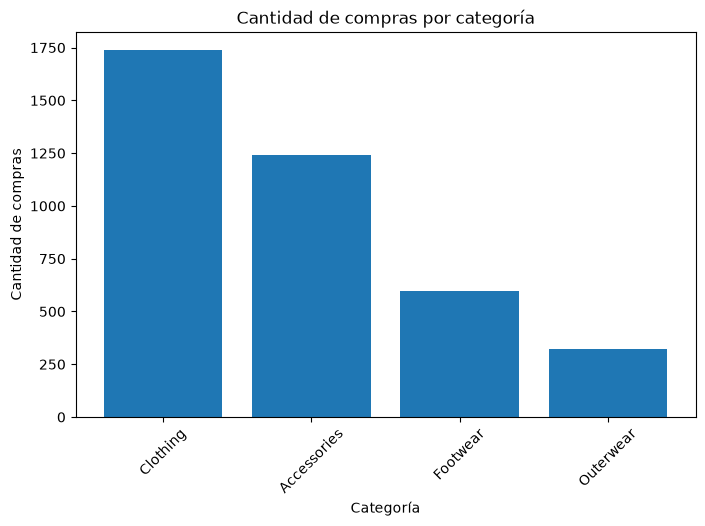

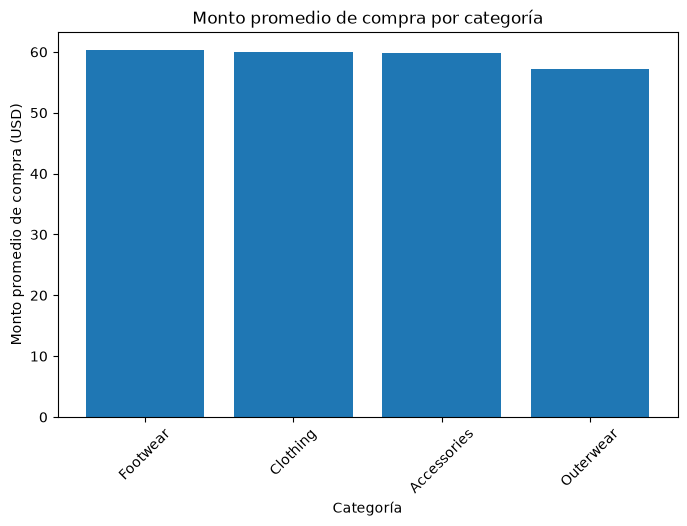

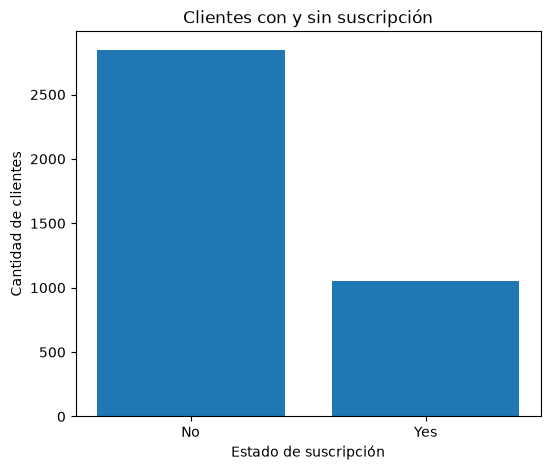

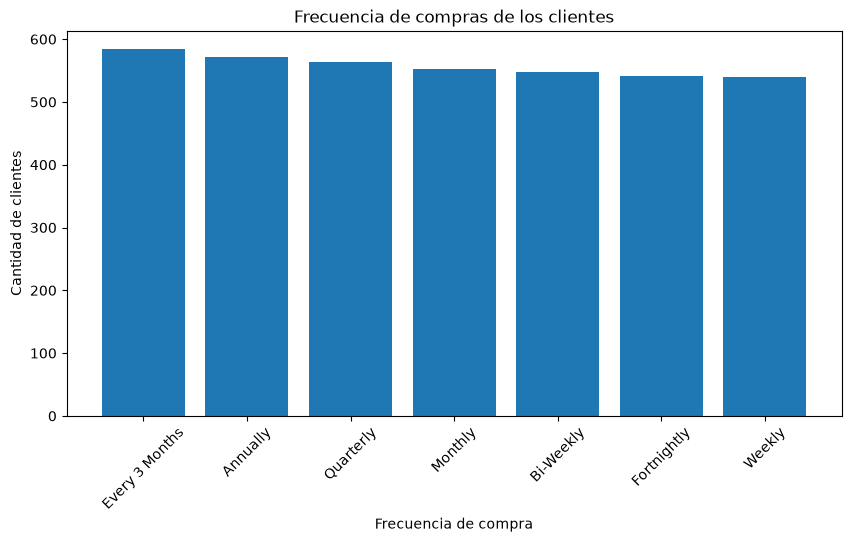


Matriz de correlación:
                            Age  Purchase Amount (USD)  Review Rating  \
Age                    1.000000              -0.010424      -0.021949   
Purchase Amount (USD) -0.010424               1.000000       0.030776   
Review Rating         -0.021949               0.030776       1.000000   
Previous Purchases     0.040445               0.008063       0.004229   

                       Previous Purchases  
Age                              0.040445  
Purchase Amount (USD)            0.008063  
Review Rating                    0.004229  
Previous Purchases               1.000000  


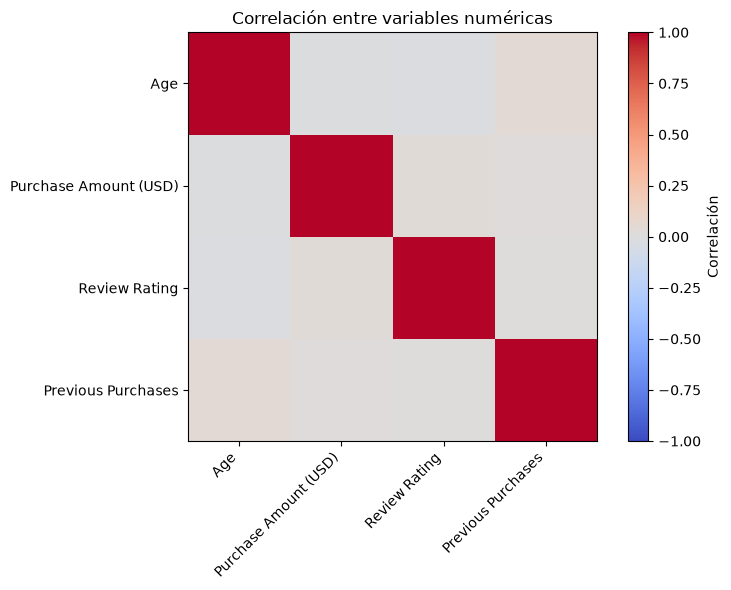


Variables utilizadas para K-Means:
['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']


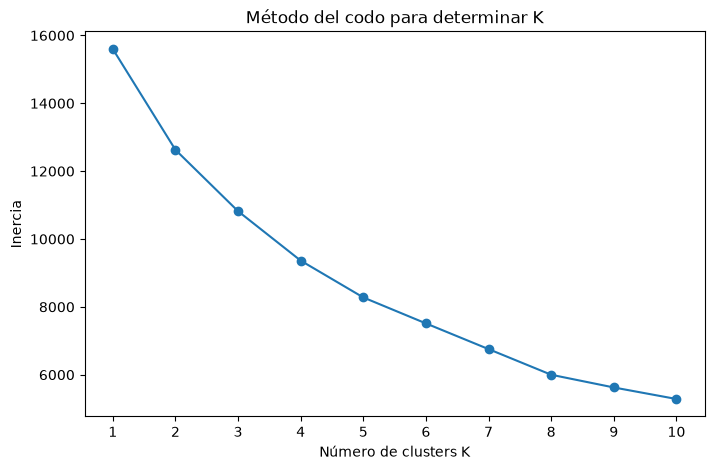


Cantidad de clientes por cluster:
Cluster
0    966
1    969
2    986
3    979
Name: count, dtype: int64

Promedios por cluster:
               Age  Purchase Amount (USD)  Review Rating  Previous Purchases
Cluster                                                                     
0        56.218427              82.076605       3.963768           26.759834
1        31.328173              54.860681       4.426316           24.984520
2        32.585193              64.758621       3.088540           22.440162
3        56.255363              37.572012       3.535649           27.257406

Medianas por cluster:
          Age  Purchase Amount (USD)  Review Rating  Previous Purchases
Cluster                                                                
0        57.0                   83.0            4.0                27.0
1        30.0                   54.0            4.5                25.0
2        32.0                   66.0            3.1                21.0
3        57.0             

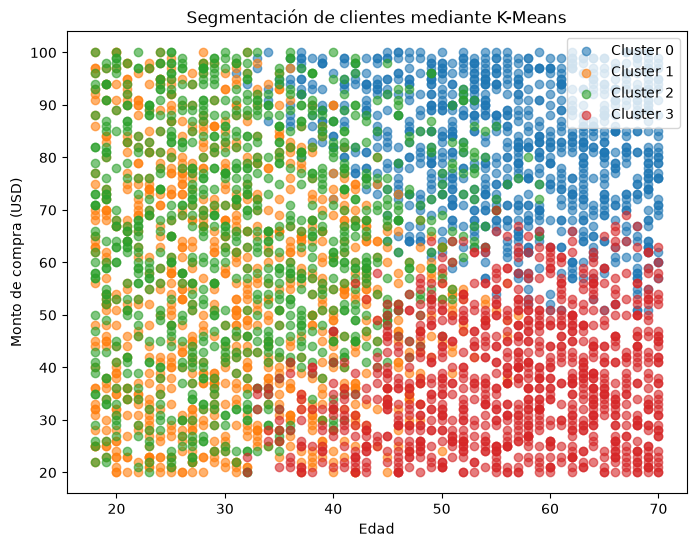


Datos para entrenamiento:
2730

Datos para prueba:
1170

Exactitud del modelo:
0.8418803418803419

Exactitud en porcentaje:
84.19 %

Exactitud que tendría un modelo que siempre eligiera la clase mayoritaria:
72.99 %

Matriz de confusión:
[[669 185]
 [  0 316]]

Orden de las clases:
['No', 'Yes']

Reporte de clasificación:
              precision    recall  f1-score   support

          No       1.00      0.78      0.88       854
         Yes       0.63      1.00      0.77       316

    accuracy                           0.84      1170
   macro avg       0.82      0.89      0.83      1170
weighted avg       0.90      0.84      0.85      1170


Primeras 20 comparaciones:
   Estado_Real Estado_Predicho
0           No              No
1          Yes             Yes
2          Yes             Yes
3           No              No
4          Yes             Yes
5          Yes             Yes
6          Yes             Yes
7           No              No
8           No              No
9         

In [2]:
# PROYECTO FINAL - MINERÍA DE DATOS
# Análisis y segmentación del comportamiento de compra de clientes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

archivo = "../data/shopping_trends.csv"
df = pd.read_csv(archivo)

print("Primeras filas del dataset:")
print(df.head())

print("\nCantidad de registros y columnas:")
print(df.shape)

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)


# LIMPIEZA Y REVISIÓN DE DATOS

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nCantidad de registros duplicados:")
print(df.duplicated().sum())

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar espacios innecesarios
columnas_texto = df.select_dtypes(include="object").columns

for columna in columnas_texto:
    df[columna] = df[columna].str.strip()

print("\nCantidad de registros después de la limpieza:")
print(len(df))

# Dataset limpio
df.to_csv("../data/shopping_trends_limpio.csv", index=False)

print("\nDataset limpio guardado como shopping_trends_limpio.csv")


# ESTADÍSTICA DESCRIPTIVA

variables_numericas = df[[
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]]

print("\nResumen estadístico:")
print(variables_numericas.describe())

print("\nMedia:")
print(variables_numericas.mean())

print("\nMediana:")
print(variables_numericas.median())

print("\nModa:")
print(variables_numericas.mode().iloc[0])

print("\nDesviación estándar:")
print(variables_numericas.std())

print("\nVarianza:")
print(variables_numericas.var())

print("\nRango:")
print(variables_numericas.max() - variables_numericas.min())


# ANÁLISIS GENERAL DEL DATASET

print("\nClientes por género:")
print(df["Gender"].value_counts())

print("\nCompras por categoría:")
print(df["Category"].value_counts())

print("\nEstado de suscripción:")
print(df["Subscription Status"].value_counts())

print("\nFrecuencia de compras:")
print(df["Frequency of Purchases"].value_counts())

print("\nCompras por temporada:")
print(df["Season"].value_counts())

print("\nPromedio de compra por categoría:")
print(
    df.groupby("Category")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)

print("\nPromedio de calificación por categoría:")
print(
    df.groupby("Category")["Review Rating"]
    .mean()
    .sort_values(ascending=False)
)


# GRÁFICA 1
# DISTRIBUCIÓN DE EDADES

plt.figure(figsize=(8, 5))

plt.hist(
    df["Age"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Edad")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de edades de los clientes")

plt.show()


# GRÁFICA 2
# CANTIDAD DE COMPRAS POR CATEGORÍA

compras_categoria = df["Category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    compras_categoria.index,
    compras_categoria.values
)

plt.xlabel("Categoría")
plt.ylabel("Cantidad de compras")
plt.title("Cantidad de compras por categoría")

plt.xticks(rotation=45)

plt.show()


# GRÁFICA 3
# MONTO PROMEDIO DE COMPRA POR CATEGORÍA

promedio_categoria = (
    df.groupby("Category")["Purchase Amount (USD)"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    promedio_categoria.index,
    promedio_categoria.values
)

plt.xlabel("Categoría")
plt.ylabel("Monto promedio de compra (USD)")
plt.title("Monto promedio de compra por categoría")

plt.xticks(rotation=45)

plt.show()


# GRÁFICA 4
# CLIENTES CON Y SIN SUSCRIPCIÓN

suscripciones = df["Subscription Status"].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    suscripciones.index,
    suscripciones.values
)

plt.xlabel("Estado de suscripción")
plt.ylabel("Cantidad de clientes")
plt.title("Clientes con y sin suscripción")

plt.show()


# GRÁFICA 5
# FRECUENCIA DE COMPRAS

frecuencia = df["Frequency of Purchases"].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(
    frecuencia.index,
    frecuencia.values
)

plt.xlabel("Frecuencia de compra")
plt.ylabel("Cantidad de clientes")
plt.title("Frecuencia de compras de los clientes")

plt.xticks(rotation=45)

plt.show()


# GRÁFICA 6
# MATRIZ DE CORRELACIÓN

correlacion = variables_numericas.corr()

print("\nMatriz de correlación:")
print(correlacion)

plt.figure(figsize=(8, 6))

plt.imshow(
    correlacion,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title("Correlación entre variables numéricas")

plt.tight_layout()
plt.show()


# VARIABLES PARA K-MEANS

variables_kmeans = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

X_kmeans = df[variables_kmeans].copy()

# Escalar variables
escalador_kmeans = StandardScaler()

X_kmeans_escalado = escalador_kmeans.fit_transform(X_kmeans)

print("\nVariables utilizadas para K-Means:")
print(variables_kmeans)


# MÉTODO DEL CODO

inercias = []

for k in range(1, 11):

    modelo_k = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo_k.fit(X_kmeans_escalado)

    inercias.append(modelo_k.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inercias,
    marker="o"
)

plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.title("Método del codo para determinar K")

plt.xticks(range(1, 11))

plt.show()


# MODELO K-MEANS

K_ELEGIDO = 4

modelo_kmeans = KMeans(
    n_clusters=K_ELEGIDO,
    random_state=42,
    n_init=10
)

clusters = modelo_kmeans.fit_predict(X_kmeans_escalado)

df["Cluster"] = clusters


# RESULTADOS DE LOS CLUSTERS

print("\nCantidad de clientes por cluster:")
print(df["Cluster"].value_counts().sort_index())

print("\nPromedios por cluster:")

resumen_clusters = df.groupby("Cluster")[
    variables_kmeans
].mean()

print(resumen_clusters)


print("\nMedianas por cluster:")

medianas_clusters = df.groupby("Cluster")[
    variables_kmeans
].median()

print(medianas_clusters)


# Dataset con los clusters obtenidos

df.to_csv("../data/shopping_trends_con_clusters.csv", index=False)

print("\nDataset con clusters guardado correctamente.")


# GRÁFICA DE CLUSTERS

plt.figure(figsize=(8, 6))

for cluster in sorted(df["Cluster"].unique()):

    datos_cluster = df[df["Cluster"] == cluster]

    plt.scatter(
        datos_cluster["Age"],
        datos_cluster["Purchase Amount (USD)"],
        label="Cluster " + str(cluster),
        alpha=0.6
    )

plt.xlabel("Edad")
plt.ylabel("Monto de compra (USD)")
plt.title("Segmentación de clientes mediante K-Means")

plt.legend()

plt.show()


# SEGUNDO COMPONENTE
# REGRESIÓN LOGÍSTICA
# OBJETIVO: PREDECIR SI EL CLIENTE TIENE SUSCRIPCIÓN


# Variables para la prediccion

variables_prediccion = [
    "Age",
    "Gender",
    "Category",
    "Purchase Amount (USD)",
    "Season",
    "Review Rating",
    "Discount Applied",
    "Previous Purchases",
    "Frequency of Purchases"
]

X = df[variables_prediccion]

y = df["Subscription Status"]


# DIVIDIR DATOS
# 70% entrenamiento y 30% prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print("\nDatos para entrenamiento:")
print(len(X_train))

print("\nDatos para prueba:")
print(len(X_test))


# VARIABLES PARA REGRESIÓN LOGÍSTICA

variables_numericas_modelo = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

variables_categoricas_modelo = [
    "Gender",
    "Category",
    "Season",
    "Discount Applied",
    "Frequency of Purchases"
]


preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_numericas_modelo
        ),

        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            variables_categoricas_modelo
        )
    ]
)


# MODELO DE REGRESIÓN LOGÍSTICA

modelo_logistico = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador
        ),

        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# ENTRENAMIENTO

modelo_logistico.fit(
    X_train,
    y_train
)


# PREDICCIONES

predicciones = modelo_logistico.predict(
    X_test
)


# EXACTITUD

exactitud = accuracy_score(
    y_test,
    predicciones
)

print("\nExactitud del modelo:")
print(exactitud)

print("\nExactitud en porcentaje:")
print(
    round(exactitud * 100, 2),
    "%"
)


# COMPARAR CONTRA UNA PREDICCIÓN BÁSICA

porcentaje_mayoritario = (
    y_test.value_counts(normalize=True).max()
)

print("\nExactitud que tendría un modelo que siempre eligiera la clase mayoritaria:")
print(
    round(porcentaje_mayoritario * 100, 2),
    "%"
)


# MATRIZ DE CONFUSIÓN

matriz = confusion_matrix(
    y_test,
    predicciones,
    labels=["No", "Yes"]
)

print("\nMatriz de confusión:")
print(matriz)

print("\nOrden de las clases:")
print(["No", "Yes"])


# REPORTE DE CLASIFICACIÓN

print("\nReporte de clasificación:")

print(
    classification_report(
        y_test,
        predicciones
    )
)


# COMPARACIÓN REAL VS PREDICCIÓN

comparacion = pd.DataFrame({
    "Estado_Real": y_test.values,
    "Estado_Predicho": predicciones
})

print("\nPrimeras 20 comparaciones:")

print(
    comparacion.head(20)
)


# PREDICCIONES DE EJEMPLO

ejemplos = X_test.head(5).copy()

ejemplos["Estado_Real"] = y_test.head(5).values

ejemplos["Estado_Predicho"] = modelo_logistico.predict(
    X_test.head(5)
)

print("\nCinco predicciones del modelo:")
print(ejemplos)


# RESUMEN FINAL DEL ANÁLISIS

print("\nRESUMEN DEL PROYECTO")

print(
    "Registros analizados:",
    len(df)
)

print(
    "Número de clusters:",
    K_ELEGIDO
)

print(
    "Exactitud del modelo predictivo:",
    round(exactitud * 100, 2),
    "%"
)

print(
    "\nEl análisis utilizó K-Means para identificar perfiles de clientes"
)

print(
    "y regresión logística para predecir el estado de suscripción."
)